# figure 1E (cumulative distributions)

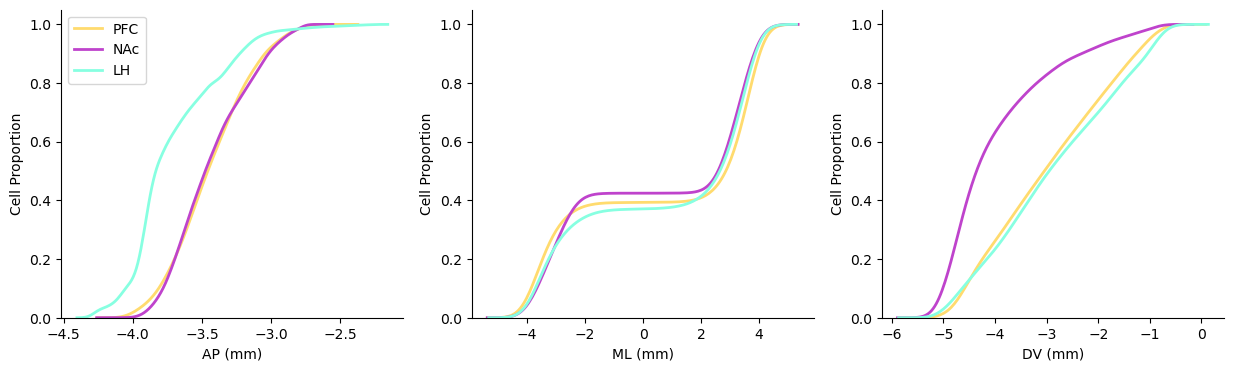

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# load .csv
df = pd.read_csv('coronal_CTBLabelled_dataset.csv')

# dict and lists for storage
colors = {'PFC': '#FFDB6E', 'NAc': '#BF43CC', 'LH': '#87FFE1'}
projections = ['PFC', 'NAc', 'LH']
axes = ['AP', 'ML', 'DV']

# 3 subplots, 3 curves in each (cell proportions projecting to each brain area vs locations on each vS axis)
fig, axes_plt = plt.subplots(1, 3, figsize=(15, 4))

for i, axis in enumerate(axes):
    for proj in projections:
        df_subset = df[df['Projection'] == proj][axis]
        sns.kdeplot(data=df_subset, ax=axes_plt[i], label=proj, color=colors[proj], lw=2, cumulative=True)
    
    axes_plt[i].set_xlabel(f'{axis} (mm)')
    axes_plt[i].set_ylabel('Cell Proportion')
    if i == 0:
        axes_plt[i].legend()

for ax in axes_plt:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
#plt.tight_layout()
plt.show()


# figure 1F (Pearson correlation)

/var/folders/r2/8rq37trx5gg1mzg8fyzcwqv40000gn/T/ipykernel_85125/3301635647.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


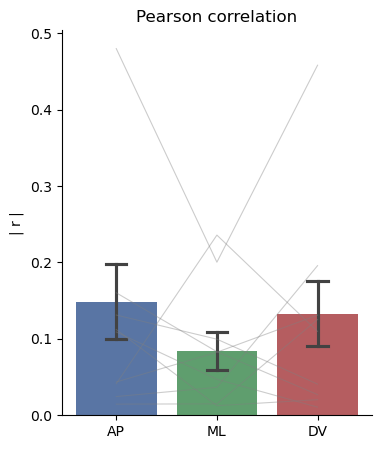

In [2]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# dist and list for storage
axes = ['AP', 'ML', 'DV']
results = {axis: [] for axis in axes}

# calculate pearson correlation
for injection in df['id'].unique():
    df_sub = df[df['id'] == injection]
        
    for axis in axes:
        x = df_sub[axis]
        y = df_sub['Projection_cat']
        
        r, p = stats.pearsonr(x, y)
        results[axis].append(abs(r))

# convert results dist into df
df_plt = pd.DataFrame({
    'axis': ['AP']*10 + ['ML']*10 + ['DV']*10,
    'r': np.concatenate([results[axis] for axis in axes]), 
    'injection': list(range(10)) * 3
})

# barplot + SEM + line
plt.figure(figsize=(4,5))

sns.barplot(
    data=df_plt,
    x='axis',
    y='r',
    palette=['#4C72B0', '#55A868', '#C44E52'],
    errorbar='se',
    capsize=0.2
)

for i in range(1, 11):
    line = df_plt[df_plt['injection'] == i]
    sns.lineplot(
        data=line,
        x='axis',
        y='r',
        color='gray',
        alpha=0.4,
        linewidth=0.8,
        legend=False
    )

plt.xlabel('')
plt.ylabel('| r |')
plt.title('Pearson correlation')
sns.despine()
plt.show()

# figure 1F (Logistic regression)

/var/folders/r2/8rq37trx5gg1mzg8fyzcwqv40000gn/T/ipykernel_85125/4072643855.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


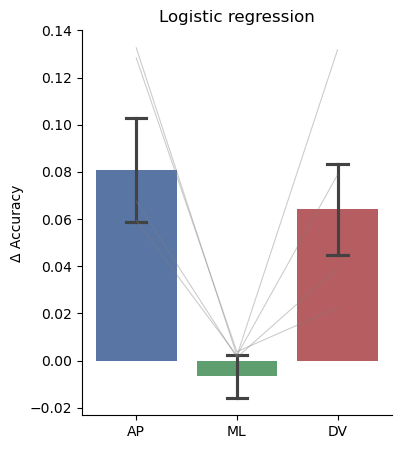

In [3]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt

x_full = df[['AP', 'ML', 'DV']]
y = df['Projection_cat']

model = LogisticRegression(max_iter=1000)

# prediction accuracy (full, after removing AP/ML/DV)
acc_full = cross_val_score(model, x_full, y, cv=5)

x_no_AP = df[['ML', 'DV']]
acc_no_AP = cross_val_score(model, x_no_AP, y, cv=5)

x_no_ML = df[['AP', 'DV']]
acc_no_ML = cross_val_score(model, x_no_ML, y, cv=5)

x_no_DV = df[['AP', 'ML']]
acc_no_DV = cross_val_score(model, x_no_DV, y, cv=5)

delta_AP = acc_full - acc_no_AP
delta_ML = acc_full - acc_no_ML
delta_DV = acc_full - acc_no_DV

# convert into df
df_plt = pd.DataFrame({
    'axis': ['AP']*5 + ['ML']*5 + ['DV']*5,
    'delta': list(delta_AP) + list(delta_ML) + list(delta_DV), 
    'fold': list(range(5)) * 3
})

plt.figure(figsize=(4,5))

# barplot + SEM + line
sns.barplot(
    data=df_plt,
    x='axis',
    y='delta',
    palette=['#4C72B0', '#55A868', '#C44E52'],
    errorbar='se',
    capsize=0.2
)

for i in range(1, 6):
    line = df_plt[df_plt['fold'] == i]
    sns.lineplot(
        data=line,
        x='axis',
        y='delta',
        color='gray',
        alpha=0.4,
        linewidth=0.8,
        legend=False
    )

plt.xlabel('')
plt.ylabel('Δ Accuracy')
plt.title('Logistic regression')
sns.despine()
#plt.tight_layout()
plt.show()